In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
df = pd.read_csv('data/data_mapping.csv', sep=',')
df

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,Single,2nd phase - general contingent,5,Animation and Multimedia Design,Daytime,Secondary education,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,Single,International student,1,Tourism,Daytime,Secondary education,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,Single,1st phase - general contingent,5,Communication Design,Daytime,Secondary education,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,Single,2nd phase - general contingent,2,Journalism and Communication,Daytime,Secondary education,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,Married,Over 23 years old,1,Social Service (evening),Evening,Secondary education,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4419,Single,1st phase - general contingent,6,Journalism and Communication,Daytime,Secondary education,125.0,1,1,1,...,0,6,8,5,12.666667,0,15.5,2.8,-4.06,Graduate
4420,Single,1st phase - general contingent,2,Journalism and Communication,Daytime,Secondary education,120.0,105,1,1,...,0,6,6,2,11.000000,0,11.1,0.6,2.02,Dropout
4421,Single,1st phase - general contingent,1,Nursing,Daytime,Secondary education,154.0,1,37,37,...,0,8,9,1,13.500000,0,13.9,-0.3,0.79,Dropout
4422,Single,1st phase - general contingent,1,Management,Daytime,Secondary education,180.0,1,37,37,...,0,5,6,5,12.000000,0,9.4,-0.8,-3.12,Graduate


In [3]:
df.describe(include='all')

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
count,4424,4424,4424.000000,4424,4424,4424,4424.000000,4424.000000,4424.000000,4424.000000,...,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424
unique,6,18,NaN,17,2,17,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
top,Single,1st phase - general contingent,NaN,Nursing,Daytime,Secondary education,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Graduate
freq,3919,1708,NaN,766,3941,3717,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2209
mean,NaN,NaN,1.727848,NaN,NaN,NaN,132.613314,1.873192,19.561935,22.275316,...,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.001969,NaN
std,NaN,NaN,1.313793,NaN,NaN,NaN,13.188332,6.914514,15.603186,15.343108,...,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,2.269935,NaN
min,NaN,NaN,0.000000,NaN,NaN,NaN,95.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000,NaN
25%,NaN,NaN,1.000000,NaN,NaN,NaN,125.000000,1.000000,2.000000,3.000000,...,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000,NaN
50%,NaN,NaN,1.000000,NaN,NaN,NaN,133.100000,1.000000,19.000000,19.000000,...,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000,NaN
75%,NaN,NaN,2.000000,NaN,NaN,NaN,140.000000,1.000000,37.000000,37.000000,...,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000,NaN


In [4]:
def value_counts(df, column):
    return df[column].value_counts()


def pivot(df, column, sort = 'Dropout'):
   return df.groupby([column, 'Status']).size().unstack(fill_value=0)

def plot_pivot(df, column, sort = 'Dropout'):
    pivot(df, column).sort_values(by=sort, ascending=True).plot(
        kind='barh',
        stacked=True,
        figsize=(10,8)
    )

    plt.title(f'Distribusi Status by {column}')
    plt.xlabel('Jumlah')
    plt.ylabel(column)
    plt.tight_layout()
    plt.show()

def plot_percentatage(df, column, sort = 'Dropout'):
    pivot(df, column).div(pivot(df, column).sum(axis=1), axis=0).sort_values(by=sort, ascending=True).plot(
        kind='barh',
        stacked=True,
        figsize=(10,8)
    )

    plt.title(f'Proporsi Status by {column}')
    plt.xlabel('Persentase')
    plt.show()

In [5]:
target = "Course"

value_counts(df, target)

Course
Nursing                                 766
Management                              380
Social Service                          355
Veterinary Nursing                      337
Journalism and Communication            331
Advertising and Marketing Management    268
Management (evening)                    268
Tourism                                 252
Communication Design                    226
Animation and Multimedia Design         215
Social Service (evening)                215
Agronomy                                210
Basic Education                         192
Informatics Engineering                 170
Equinculture                            141
Oral Hygiene                             86
Biofuel Production Technologies          12
Name: count, dtype: int64

In [6]:
pivot(df, target).sort_values(by="Dropout", ascending=False)

Status,Dropout,Enrolled,Graduate
Course,,,
Management (evening),136,54,78
Management,134,108,138
Nursing,118,100,548
Journalism and Communication,101,34,196
Tourism,96,41,115
Advertising and Marketing Management,95,48,125
Informatics Engineering,92,64,14
Veterinary Nursing,90,75,172
Agronomy,86,37,87


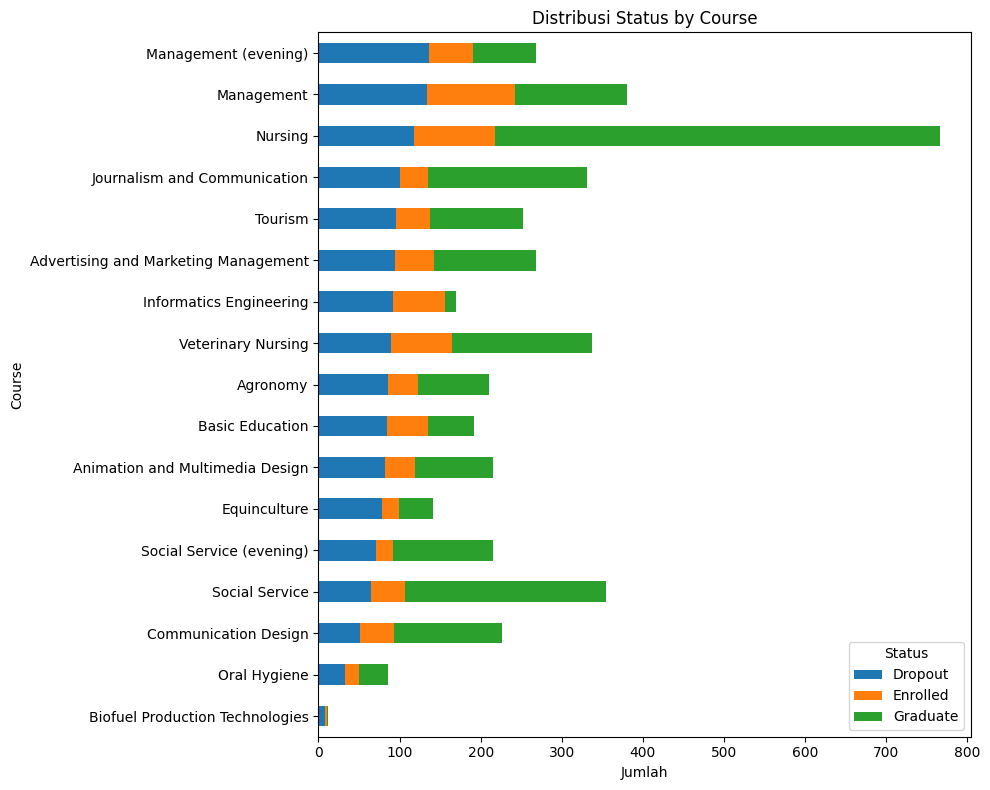

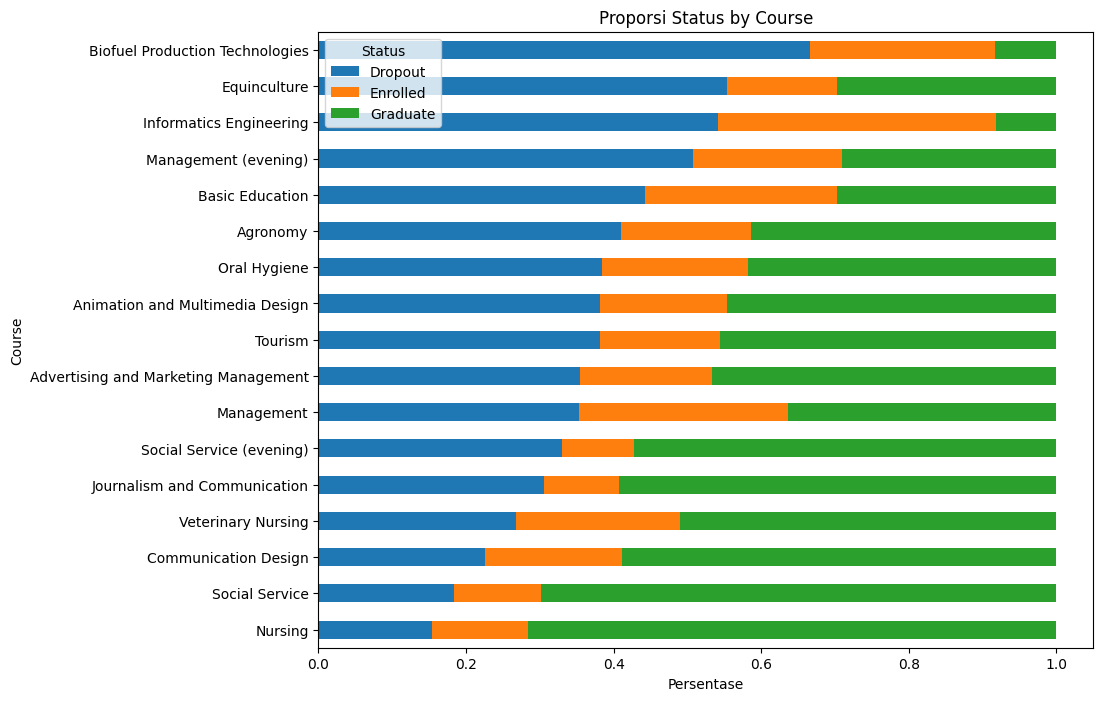

In [7]:
plot_pivot(df, target)
plot_percentatage(df, target)

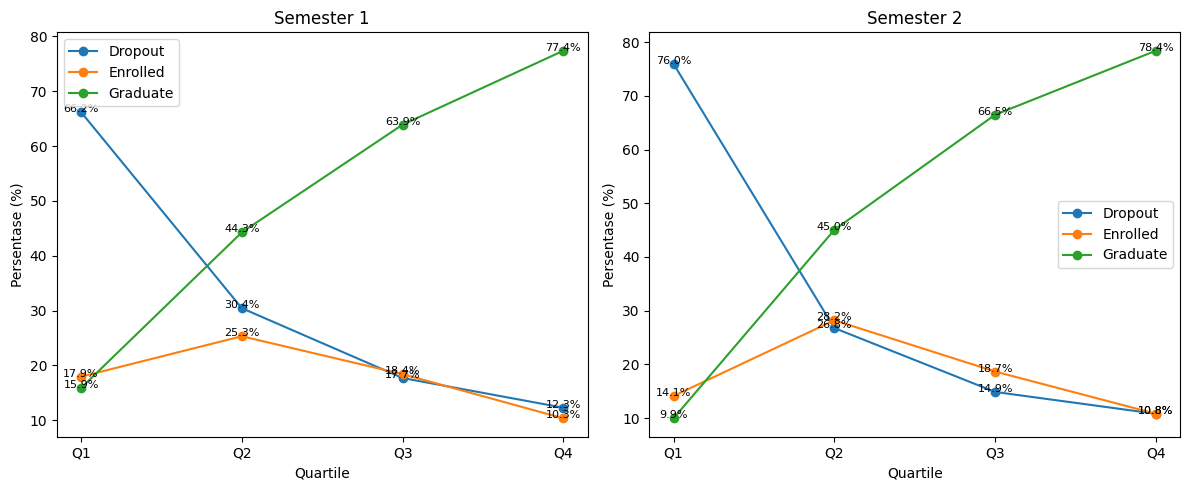

In [16]:
df['Sem1_Category'] = pd.qcut(
    df['Curricular_units_1st_sem_grade'],
    q=4,
    labels=['Q1', 'Q2', 'Q3', 'Q4']
)

df['Sem2_Category'] = pd.qcut(
    df['Curricular_units_2nd_sem_grade'],
    q=4,
    labels=['Q1', 'Q2', 'Q3', 'Q4']
)

# ========================
# DISTRIBUSI (%)
# ========================
sem1_dist = pd.crosstab(df['Sem1_Category'], df['Status'], normalize='index') * 100
sem2_dist = pd.crosstab(df['Sem2_Category'], df['Status'], normalize='index') * 100

# ========================
# PLOT LINE + VALUE
# ========================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ---------- SEM 1 ----------
for col in sem1_dist.columns:
    axes[0].plot(sem1_dist.index, sem1_dist[col], marker='o', label=col)
    
    # kasih label angka
    for x, y in zip(sem1_dist.index, sem1_dist[col]):
        axes[0].text(x, y, f'{y:.1f}%', ha='center', fontsize=8)

axes[0].set_title('Semester 1')
axes[0].set_xlabel('Quartile')
axes[0].set_ylabel('Persentase (%)')
axes[0].legend()

# ---------- SEM 2 ----------
for col in sem2_dist.columns:
    axes[1].plot(sem2_dist.index, sem2_dist[col], marker='o', label=col)
    
    for x, y in zip(sem2_dist.index, sem2_dist[col]):
        axes[1].text(x, y, f'{y:.1f}%', ha='center', fontsize=8)

axes[1].set_title('Semester 2')
axes[1].set_xlabel('Quartile')
axes[1].set_ylabel('Persentase (%)')
axes[1].legend()

plt.tight_layout()
plt.show()

In [20]:
sem1_range = df.groupby('Sem1_Category')['Curricular_units_1st_sem_grade'].agg(['min', 'max'])
sem2_range = df.groupby('Sem2_Category')['Curricular_units_2nd_sem_grade'].agg(['min', 'max'])

print("=== Semester 1 ===")
print(sem1_range)

print("\n=== Semester 2 ===")
print(sem2_range)

=== Semester 1 ===
                     min        max
Sem1_Category                      
Q1              0.000000  11.000000
Q2             11.071429  12.285714
Q3             12.288000  13.400000
Q4             13.403750  18.875000

=== Semester 2 ===
                     min        max
Sem2_Category                      
Q1              0.000000  10.750000
Q2             10.800000  12.200000
Q3             12.205556  13.333333
Q4             13.342500  18.571429


In [27]:
sem1_range = df.pivot_table(
    values='Curricular_units_1st_sem_grade',
    index='Sem1_Category',
    columns='Status',
    aggfunc=[ 'count']
)

sem2_range = df.pivot_table(
    values='Curricular_units_1st_sem_grade',
    index='Sem2_Category',
    columns='Status',
    aggfunc=[ 'count']
)

print("=== Semester 1 ===")
print(sem1_range)

print("\n=== Semester 2 ===")
print(sem2_range)

=== Semester 1 ===
                count                  
Status        Dropout Enrolled Graduate
Sem1_Category                          
Q1                768      208      184
Q2                321      267      467
Q3                199      207      719
Q4                133      112      839

=== Semester 2 ===
                count                  
Status        Dropout Enrolled Graduate
Sem2_Category                          
Q1                841      156      110
Q2                297      313      500
Q3                164      206      734
Q4                119      119      865
